<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_9_Image_to_Text_and_Audio_Conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Project 9: Image to Text and Audio Conversion
# Install system dependencies
!apt-get update
!apt-get install -y tesseract-ocr
!apt-get install -y ffmpeg

# Install Python libraries
!pip install pytesseract opencv-python matplotlib gtts SpeechRecognition pydub

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 

In [21]:
# Import Libraries
import cv2
import pytesseract
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio, display
import speech_recognition as sr
import os

# Tesseract path
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

In [22]:
# Upload Image
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print("Uploaded Image:", image_path)

Saving text1.png to text1 (1).png
Uploaded Image: text1 (1).png


(np.float64(-0.5), np.float64(699.5), np.float64(439.5), np.float64(-0.5))

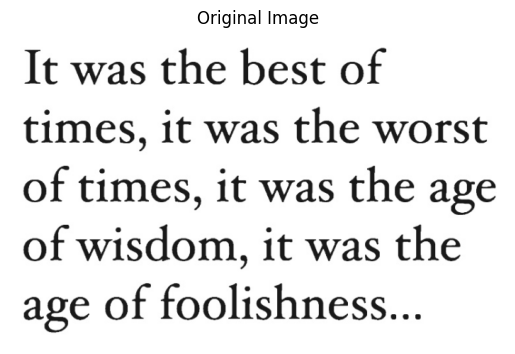

In [23]:
# Display Original Image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(699.5), np.float64(439.5), np.float64(-0.5))

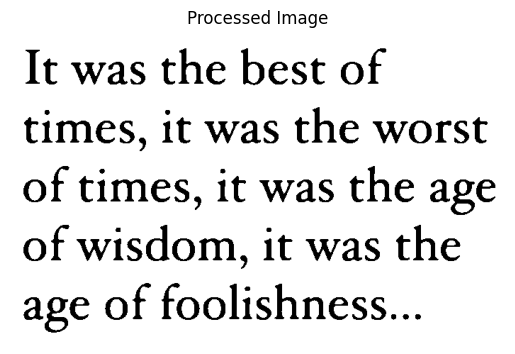

In [24]:
# Image Preprocessing
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Thresholding (Binarization)
_, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)

# Show processed image
plt.imshow(thresh, cmap='gray')
plt.title("Processed Image")
plt.axis("off")

(np.float64(-0.5), np.float64(699.5), np.float64(439.5), np.float64(-0.5))

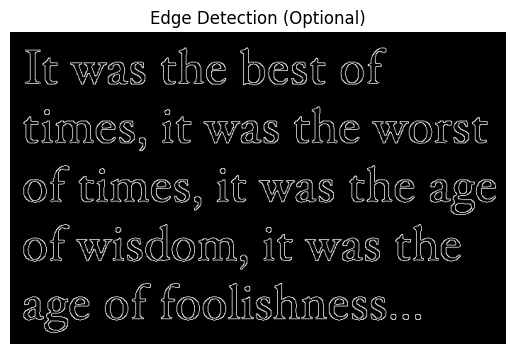

In [25]:
# Trying Edge Detection
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Optional)")
plt.axis("off")

In [26]:
# Extract Text using OCR
# OCR extraction
text = pytesseract.image_to_string(thresh)

print("Extracted Text:\n")
print(text)

Extracted Text:

It was the best of
times, it was the worst
of times, it was the age
of wisdom, it was the
age of foolishness...



In [27]:
# Save Extracted Text to File
with open("extracted_text.txt", "w") as f:
    f.write(text)

print("Text saved as extracted_text.txt")

Text saved as extracted_text.txt


In [28]:
# Convert Text to Speech
tts = gTTS(text=text, lang='en')

audio_file = "output.mp3"
tts.save(audio_file)

print("Audio file saved as output.mp3")

Audio file saved as output.mp3


In [29]:
# Play Audio
display(Audio(audio_file, autoplay=True))

In [30]:
# Download Audio File
files.download(audio_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Speech-to-Text
uploaded_audio = files.upload()
audio_path = list(uploaded_audio.keys())[0]

print("Uploaded Audio:", audio_path)

Saving output.mp3 to output (2).mp3
Uploaded Audio: output (2).mp3


In [32]:
from pydub import AudioSegment
import speech_recognition as sr

# Convert MP3 to WAV
sound = AudioSegment.from_mp3(audio_path)
wav_path = "converted.wav"
sound.export(wav_path, format="wav")

print("Converted to WAV format")

# Speech Recognition
recognizer = sr.Recognizer()

with sr.AudioFile(wav_path) as source:
    audio_data = recognizer.record(source)

try:
    stt_text = recognizer.recognize_google(audio_data)
    print("Converted Speech to Text:\n")
    print(stt_text)

except Exception as e:
    print("Error:", e)

Converted to WAV format
Converted Speech to Text:

it was the best of times it was the worst of times it was the age of wisdom it was the age of foolishness


In [33]:
# Comparison
print("Comparison:\n")

print("Original Extracted Text:\n", text)
print("\nSpeech-to-Text Output:\n", stt_text)

Comparison:

Original Extracted Text:
 It was the best of
times, it was the worst
of times, it was the age
of wisdom, it was the
age of foolishness...


Speech-to-Text Output:
 it was the best of times it was the worst of times it was the age of wisdom it was the age of foolishness


# Conclusion

- OCR successfully extracts text from images
- Image preprocessing improves accuracy
- Text converted into speech (MP3)
- Speech successfully converted back into text

# Observations:
- Printed text works better than handwritten text
- Noise reduction improves OCR accuracy
- Clear images produce better results

# Future Improvements:
- Use deep learning OCR (EasyOCR, TrOCR)
- Improve preprocessing for handwritten text
- Add GUI interface